# Exploratory Data Analysis (EDA)
## Dataset Aspect-Based Sentiment Analysis (ABSA)
Sumber: Review Google Places

### Deskripsi
Notebook ini bertujuan untuk menganalisis karakteristik dataset hasil anotasi ABSA
dengan aspek:
- Product
- Price
- Place
- Promotion

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from sklearn.preprocessing import MultiLabelBinarizer

sns.set(style="whitegrid")

data = []
error_lines = []

file_path = "db_nlp2_genap2526_clean_iaa.jsonl"

with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        try:
            data.append(json.loads(line))
        except Exception as e:
            error_lines.append((i+1, str(e)))

df = pd.DataFrame(data)

print("\nJumlah data berhasil:", len(df))
print("Jumlah error:", len(error_lines))

df.info()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

if 'clean_text' in df.columns:
    df['clean_text'] = df['clean_text'].apply(clean_text)
elif 'text' in df.columns:
    df['clean_text'] = df['text'].apply(clean_text)


Jumlah data berhasil: 678
Jumlah error: 1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678 entries, 0 to 677
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           678 non-null    object
 1   tokens         678 non-null    object
 2   spans          678 non-null    object
 3   _input_hash    678 non-null    int64 
 4   _task_hash     678 non-null    int64 
 5   options        678 non-null    object
 6   _view_id       678 non-null    object
 7   config         678 non-null    object
 8   accept         678 non-null    object
 9   answer         678 non-null    object
 10  _timestamp     678 non-null    int64 
 11  _annotator_id  678 non-null    object
 12  _session_id    678 non-null    object
 13  flagged        1 non-null      object
dtypes: int64(3), object(11)
memory usage: 74.3+ KB


Dataset yang digunakan dalam analisis ini merupakan hasil proses cleaning dari data anotasi awal. Setelah proses pembersihan data, jumlah data yang dapat digunakan sebanyak 678 review.

Jumlah ini berada di bawah ketentuan minimum proyek (800 data), namun tetap digunakan untuk menjaga kualitas data yang dianalisis, dengan menghindari data yang tidak valid atau rusak.

In [31]:
df['label'] = df['accept'].apply(lambda x: x if isinstance(x, list) else []) if 'accept' in df.columns else [[] for _ in range(len(df))]
df['spans'] = df['spans'].apply(lambda x: x if isinstance(x, list) else []) if 'spans' in df.columns else [[] for _ in range(len(df))]

df['word_count'] = df['clean_text'].apply(lambda x: len(str(x).split()))

print("Kolom yang tersedia:", df.columns.tolist())
print("Jumlah baris:", len(df))

Kolom yang tersedia: ['text', 'tokens', 'spans', '_input_hash', '_task_hash', 'options', '_view_id', 'config', 'accept', 'answer', '_timestamp', '_annotator_id', '_session_id', 'flagged', 'clean_text', 'label', 'word_count']
Jumlah baris: 678


              label  count
0  PRODUCT_POSITIVE    526
1    PLACE_POSITIVE    229
2    PRICE_POSITIVE    111
3  PRODUCT_NEGATIVE     38
4      OUT_OF_TOPIC     38


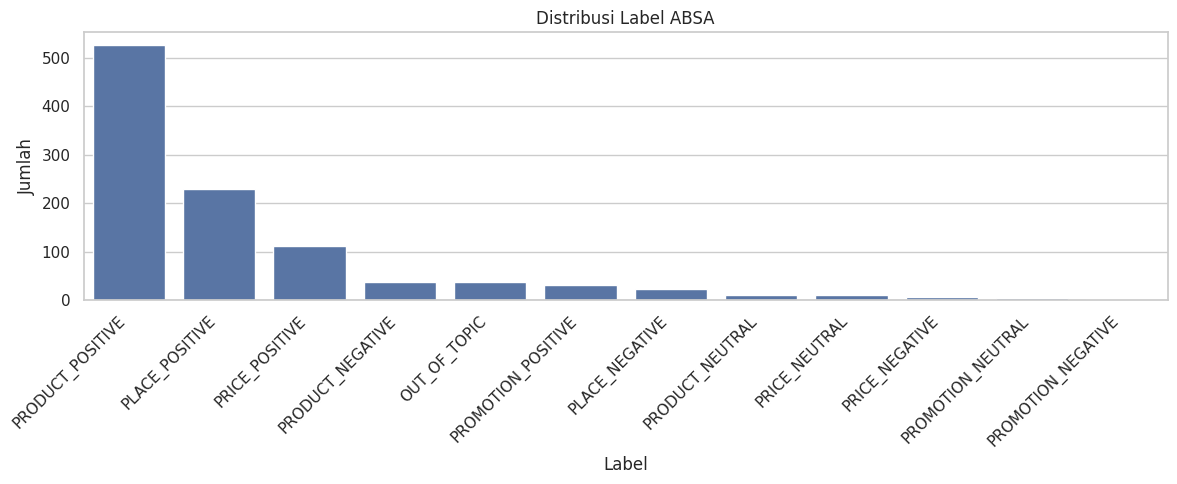

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

if 'accept' not in df.columns:
    raise ValueError("Kolom 'accept' tidak ditemukan di dataframe")

label_counts = (
    df['accept']
    .dropna()
    .explode()
    .value_counts()
    .reset_index()
)

label_counts.columns = ['label', 'count']

label_counts = label_counts.sort_values(by='count', ascending=False)

print(label_counts.head())

plt.figure(figsize=(12, 5))
sns.barplot(data=label_counts, x='label', y='count')

plt.xticks(rotation=45, ha='right')
plt.title("Distribusi Label ABSA")
plt.xlabel("Label")
plt.ylabel("Jumlah")

plt.tight_layout()
plt.show()

Berdasarkan distribusi label ABSA, terlihat bahwa label yang paling dominan adalah PRODUCT_POSITIVE dengan jumlah 526, diikuti oleh PLACE_POSITIVE dan PRICE_POSITIVE. Hal ini menunjukkan bahwa mayoritas ulasan cenderung memberikan sentimen positif, khususnya terhadap aspek produk.

Sebaliknya, label negatif seperti PRODUCT_NEGATIVE memiliki jumlah yang jauh lebih sedikit, dan beberapa label seperti OUT_OF_TOPIC juga memiliki frekuensi rendah. Hal ini menunjukkan adanya ketidakseimbangan distribusi label dalam dataset.

Dominasi label positif ini mengindikasikan bahwa pengguna lebih sering memberikan ulasan positif dibandingkan negatif, yang berpotensi menyebabkan bias pada model dalam memprediksi sentimen.

               entity  count
0    PRODUCT_POSITIVE    717
1      PLACE_POSITIVE    289
2      PRICE_POSITIVE    108
3        OUT_OF_TOPIC     41
4  PROMOTION_POSITIVE     33


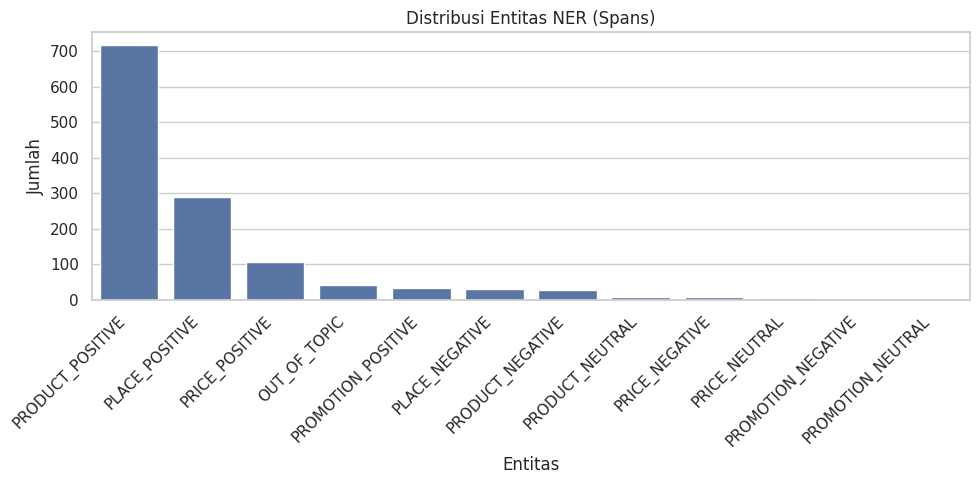

In [35]:
entities = []

for spans in df['spans']:
  if isinstance(spans, list):
    for s in spans:
        if isinstance(s, dict) and 'label' in s:
            entities.append(s['label'])

entity_counts = pd.Series(entities).value_counts().reset_index()
entity_counts.columns = ['entity', 'count']

entity_counts = entity_counts.sort_values(by='count', ascending=False)

print(entity_counts.head())

plt.figure(figsize=(10, 5))
sns.barplot(data=entity_counts, x='entity', y='count')

plt.xticks(rotation=45, ha='right')
plt.title("Distribusi Entitas NER (Spans)")
plt.xlabel("Entitas")
plt.ylabel("Jumlah")

plt.tight_layout()
plt.show()

Berdasarkan distribusi entitas, terlihat bahwa entitas yang paling dominan adalah PRODUCT_POSITIVE dengan jumlah 717, diikuti oleh PLACE_POSITIVE sebanyak 289 dan PRICE_POSITIVE sebanyak 108. Hal ini menunjukkan bahwa sebagian besar anotasi dalam dataset berfokus pada aspek produk, diikuti oleh pengalaman di tempat dan harga.

Selain itu, entitas seperti OUT_OF_TOPIC dan PROMOTION_POSITIVE memiliki jumlah yang relatif kecil dibandingkan kategori utama. Hal ini menunjukkan adanya ketidakseimbangan distribusi entitas, di mana beberapa kategori memiliki jumlah data yang jauh lebih sedikit.

Dominasi entitas PRODUCT_POSITIVE mengindikasikan bahwa pengguna lebih sering menyoroti kualitas produk secara positif dalam ulasan mereka. Kondisi ini dapat mempengaruhi performa model, khususnya dalam mengenali entitas yang jarang muncul.

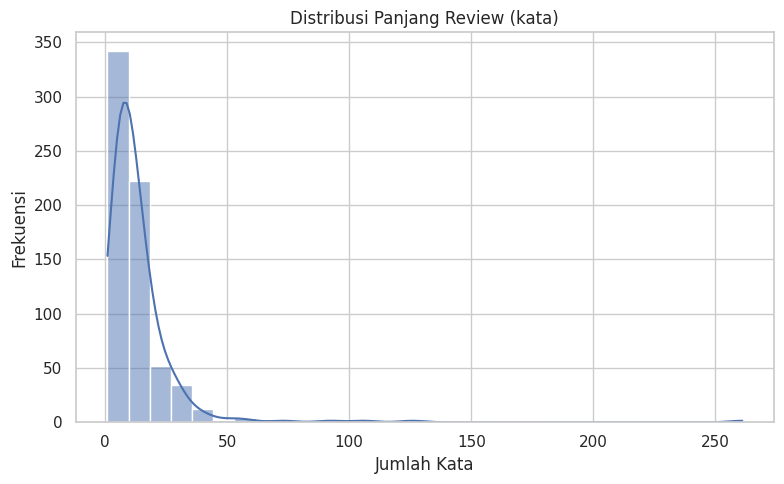

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title("Distribusi Panjang Review (kata)")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

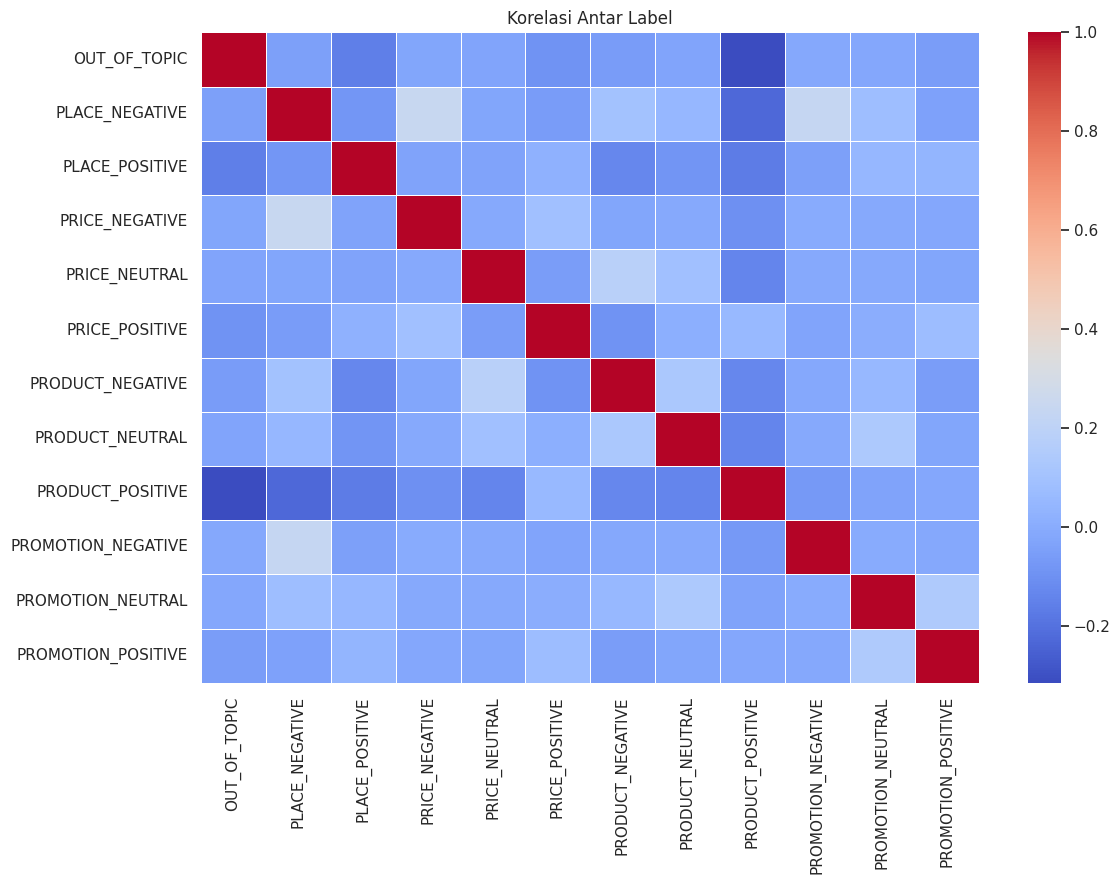

In [ ]:
mlb = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(df['label'])
label_df = pd.DataFrame(label_matrix, columns=mlb.classes_)

plt.figure(figsize=(12, 9))
sns.heatmap(label_df.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Korelasi Antar Label")
plt.tight_layout()
plt.show()

In [ ]:
print("\n=== Statistik Dataset ===")
print("Jumlah data       :", len(df))
print("Rata-rata panjang :", round(df['word_count'].mean(), 2))
print("Review terpanjang :", df['word_count'].max())
print("Review terpendek  :", df['word_count'].min())


=== Statistik Dataset ===
Jumlah data       : 678
Rata-rata panjang : 13.72
Review terpanjang : 261
Review terpendek  : 1


In [ ]:
print("\nSample data:")
print(df[['text', 'label']].sample(5))


Sample data:
                                                  text  \
51   updatee untuk modelmodelnya dan yang pasti pel...   
410            ukuran sesuai bahan nyaman warna sesuai   
428  pertama pengiriman mantep banget 2 hari sampe ...   
174  kasirnya ramah dan mau membantu pelayanan di s...   
316  bahan nya tebal adem jahitan tapi sangat recom...   

                                  label  
51   [PRODUCT_POSITIVE, PLACE_POSITIVE]  
410                  [PRODUCT_POSITIVE]  
428                    [PLACE_POSITIVE]  
174                    [PLACE_POSITIVE]  
316                                  []  


## Inter-Annotator Agreement (IRR)

Bagian ini bertujuan untuk mengevaluasi tingkat kesepakatan antar annotator dalam proses anotasi dataset menggunakan beberapa metrik seperti Krippendorff Alpha, Percent Agreement, dan Gwet AC2.

In [40]:
import json
import pandas as pd

with open("nlp2_iaaa_textcat.jsonl", "r") as f:
    textcat_irr = json.load(f)

df_irr = pd.DataFrame(textcat_irr).T

df_irr_summary = df_irr[["kripp_alpha", "percent_agreement", "gwet_ac2"]].copy()

def interpret_alpha(alpha):
    if pd.isna(alpha):
        return "Tidak ada data"
    elif alpha >= 0.8:
        return "Sangat Baik"
    elif alpha >= 0.6:
        return "Baik"
    elif alpha >= 0.4:
        return "Cukup"
    elif alpha >= 0.2:
        return "Rendah"
    else:
        return "Sangat Rendah"

df_irr_summary["kategori"] = df_irr_summary["kripp_alpha"].apply(interpret_alpha)
df_irr_summary = df_irr_summary.sort_values(by="kripp_alpha", ascending=False)
df_irr_summary

,kripp_alpha,percent_agreement,gwet_ac2,kategori
PRICE_POSITIVE,0.904965,0.971491,0.958979,Sangat Baik
PLACE_POSITIVE,0.767055,0.892544,0.800461,Baik
PLACE_NEGATIVE,0.740130,0.980576,0.978984,Baik
PRODUCT_POSITIVE,0.721596,0.896930,0.835494,Baik
PRODUCT_NEGATIVE,0.704467,0.954887,0.946897,Baik
PROMOTION_POSITIVE,0.613412,0.984962,0.984310,Baik
OUT_OF_TOPIC,0.515148,0.960213,0.956487,Cukup
PRICE_NEGATIVE,0.286245,0.987469,0.987258,Rendah
PRODUCT_NEUTRAL,0.230657,0.970551,0.969405,Rendah
PRICE_NEUTRAL,0.153289,0.985902,0.985644,Sangat Rendah


Berdasarkan hasil Inter-Annotator Agreement (IRR), terlihat bahwa label dengan sentimen positif memiliki tingkat kesepakatan yang relatif tinggi. Hal ini ditunjukkan oleh nilai Krippendorff’s Alpha yang berada pada kategori baik hingga sangat baik, seperti pada PRICE_POSITIVE (0.90) dan beberapa label positif lainnya.

Sebaliknya, label dengan sentimen netral dan beberapa kategori negatif menunjukkan nilai alpha yang rendah hingga sangat rendah. Bahkan terdapat label seperti PROMOTION_NEGATIVE yang memiliki nilai mendekati nol, yang mengindikasikan hampir tidak adanya kesepakatan antar anotator.

Pola ini menunjukkan bahwa anotator cenderung lebih konsisten dalam mengidentifikasi sentimen positif dibandingkan netral atau negatif. Hal ini kemungkinan disebabkan oleh ambiguitas dalam definisi label netral atau kesulitan dalam membedakan konteks tertentu, terutama pada kategori promosi.

Kondisi ini mengindikasikan adanya ketidakseimbangan kualitas anotasi antar label, yang berpotensi mempengaruhi performa model dalam mengenali kategori dengan tingkat kesepakatan rendah.

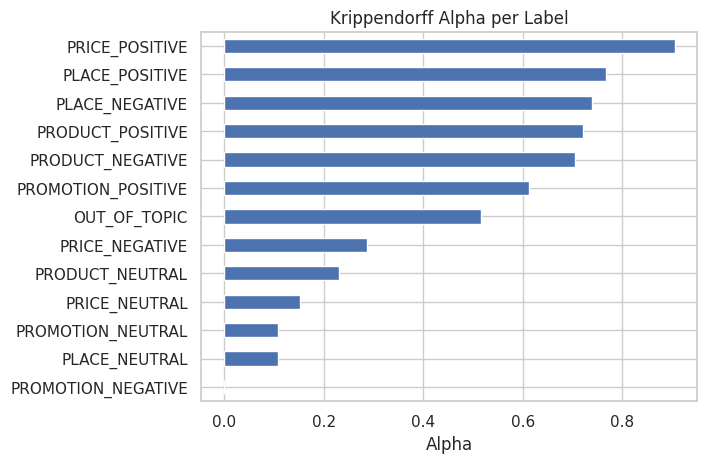

In [37]:
df_irr_summary["kripp_alpha"].sort_values().plot(kind="barh")
plt.title("Krippendorff Alpha per Label")
plt.xlabel("Alpha")
plt.show()

In [25]:
with open("nlp2_iaaa.jsonl") as f:
    iaaa = json.load(f)

print("Pairwise F1:", iaaa["pairwise_f1"])
print("Pairwise Precision:", iaaa["pairwise_precision"])
print("Pairwise Recall:", iaaa["pairwise_recall"])

Pairwise F1: 0.26
Pairwise Precision: 0.26
Pairwise Recall: 0.28


Berdasarkan metrik pairwise F1, precision, dan recall, nilai yang relatif rendah menunjukkan bahwa tingkat kesepakatan antar annotator dalam memberikan label masih belum optimal.

Hal ini memperkuat temuan sebelumnya bahwa terdapat ketidakkonsistenan dalam proses anotasi, terutama pada label dengan distribusi data yang tidak seimbang dan definisi yang ambigu.

Secara keseluruhan, kualitas anotasi dataset berada pada tingkat menengah. Beberapa label utama menunjukkan konsistensi yang baik, namun masih terdapat label dengan tingkat agreement rendah yang perlu diperbaiki melalui penyempurnaan guideline anotasi dan penambahan contoh yang lebih jelas.